# 19 - Final comparison: every run, the gate story, and the corrected verdict

This is the integration notebook. It trains nothing and computes nothing new about the models: it
reads the eleven recorded runs off disk, puts them side by side with their intervals, and states what
we are willing to claim. It is the notebook the results chapter is written from, so every table in it
goes through `report.save_table` and no number in the report should ever be retyped by hand.

**The sentence to open the chapter with**, which came out of Stream C and is the best summary anyone
produced today:

> A test that could never fail, a gate that could never pass, an interval that could not see the
> dominant source of variation. All three ran, returned clean answers, and were believed.

That is the honest shape of the day. Verification 7 truncated on the same clock it was verifying, so
it passed by construction. The as-of gate was fitted to a constant that was standing in for a number
already recorded on disk. And every confidence interval we quoted resampled evaluation rows, which
for two of three model families is the whole story and for the third misses the term that dominates.
None of the three was sloppy. Each was a reasonable thing to build, and each returned a clean answer
that nobody had reason to doubt.

**What actually changed, in one paragraph.** The leak was real and the fix was real. The V3 verdict
does not flip: the thirteen lender features do not buy a gradient-boosted model anything it cannot
already read off the mortgage-count columns in the base set. What changed is that the verdict is now
per-model rather than global, it carries intervals, the comparisons are paired, and the gate story
gained a fifth act nobody planned: a ladder of three gate settings which shows that some of what
survives on `lending` is **still** lookahead rather than signal.

## Setup

In [1]:
import json
import os
import pickle
import sys
from dataclasses import replace
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models import report, train

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

# Same three hues as notebook 17, same families, so the two notebooks read as one document.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
FAMILY = {"lightgbm": BLUE, "logistic": ORANGE, "mlp": AQUA}
INK, MUTED, RULE = "#0b0b0b", "#52514e", "#bdbdb8"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": RULE, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
})

STAGE = Path("data/processed/run_stage")
TARGETS = ["lending", "insolvency", "voluntary_exit", "growth"]
MODELS = ["lightgbm", "logistic", "mlp"]

idx = pd.read_csv("reports/runs/index.csv")
print(f"{idx['tag'].nunique()} tags, {len(idx)} run x target x model rows")

11 tags, 128 run x target x model rows


---

# 1. Every run, every model, with intervals

Eleven tags. Two things to read carefully before anything else.

**`baseline` has eight rows, not twelve.** It predates the MLP, so it holds two model families rather
than three. It is kept because it is the original reference the whole project was measured against,
but it is not a like-for-like row and should not be put in a table next to the others without that
note.

**Five tags have no intervals, and that is a date rather than a defect.** The bootstrap landed on
7 August with Stream B, so every run recorded before it has a point estimate and nothing else. Those
cells are shown as `not recorded`, never as blank or zero, because a missing interval and a narrow
interval are very different claims. The five are the pre-bootstrap runs; the six recorded afterwards
carry intervals throughout.

Everything the report quotes should come from one of the six, and in practice from `refactor_det`
(the control) and the `lender_calib*` family (the gate ladder).

In [2]:
runs = idx.copy()
runs["has_interval"] = runs["roc_auc_lo"].notna()

coverage = (runs.groupby("tag")
            .agg(rows=("target", "size"), families=("model", "nunique"),
                 targets=("target", "nunique"), intervals=("has_interval", "all"))
            .sort_values(["intervals", "tag"]))
print(coverage.to_string())
print()
print(f"tags with intervals: {int(coverage['intervals'].sum())} of {len(coverage)}")
print(f"tags without      : {sorted(coverage.index[~coverage['intervals']])}")

                    rows  families  targets  intervals
tag                                                   
baseline               8         2        4      False
lender                12         3        4      False
lender_asof21         12         3        4      False
lender_fixed          12         3        4      False
refactor              12         3        4      False
lender_asof21_det     12         3        4       True
lender_calib          12         3        4       True
lender_calib_hi       12         3        4       True
lender_calib_lo       12         3        4       True
refactor_det          12         3        4       True
refactor_growthfix    12         3        4       True

tags with intervals: 6 of 11
tags without      : ['baseline', 'lender', 'lender_asof21', 'lender_fixed', 'refactor']


In [3]:
def fmt_interval(lo, hi, dp=4):
    """An interval, or an explicit `not recorded`. Never a blank cell."""
    if pd.isna(lo) or pd.isna(hi):
        return "not recorded"
    return f"[{lo:.{dp}f}, {hi:.{dp}f}]"


all_runs = runs.assign(
    roc_auc_ci=[fmt_interval(a, b) for a, b in
                zip(runs["roc_auc_lo"], runs["roc_auc_hi"])],
    precision_at_500_ci=[fmt_interval(a, b, dp=3) for a, b in
                         zip(runs["precision_at_500_lo"], runs["precision_at_500_hi"])],
)[["tag", "target", "model", "n_features", "base_rate", "roc_auc", "roc_auc_ci",
   "precision_at_500", "precision_at_500_ci", "pr_auc", "train_rows"]]

print(all_runs[all_runs["target"] == "lending"].to_string(index=False,
      float_format=lambda v: f"{v:.4f}"))
print(report.save_table(all_runs, "19_all_runs",
                        "Every recorded run by target and model family, with 95% row-bootstrap "
                        "intervals where they were recorded."))

               tag  target    model  n_features  base_rate  roc_auc       roc_auc_ci  precision_at_500 precision_at_500_ci  pr_auc  train_rows
          baseline lending lightgbm          41     0.0027   0.8767     not recorded            0.2820        not recorded  0.0567      214708
          baseline lending logistic          41     0.0027   0.8615     not recorded            0.1500        not recorded  0.0403      214708
            lender lending lightgbm          54     0.0027   0.8951     not recorded            0.9920        not recorded  0.2074      214708
            lender lending logistic          54     0.0027   0.8812     not recorded            0.1940        not recorded  0.0691      214708
            lender lending      mlp          54     0.0027   0.8876     not recorded            0.7900        not recorded  0.1387      214708
     lender_asof21 lending lightgbm          54     0.0027   0.8763     not recorded            0.3100        not recorded  0.0558      214708

---

# 2. The gate story, in five acts

This is the spine of the chapter. One target (`lending`), one model (LightGBM), one metric
(precision@500), and a control that never moves. Everything else is held fixed, so the column is a
readout of the as-of gate and nothing else.

| act | tag | the gate | what we believed at the time |
|---|---|---|---|
| control | `refactor_det` | no lender features at all | the 41-feature baseline |
| 1 | `lender` | `created_on` | the features are as-of the month they describe |
| 2 | `lender_fixed` | `delivered_on` | using the date the registrar received it fixes it |
| 3 | `lender_asof21` | `delivered_on` + 21 days, nominal 1st of month | a measured registration lag closes the gap |
| 4 | `lender_calib` | real extract date + 4 days, satisfactions + 1 | the drift was recorded all along |
| 5 | `_hi` / `_lo` | 7d/3d and 2d/1d | sensitivity, because a point estimate of a gate is a claim |

Act 1 is the leak: precision@500 of 0.992 against a base rate of 0.27%. Act 2 halves the distortion
and leaves it obviously wrong. Act 3 is the flat 21 days, which lands close to the control and was
read as "the features buy nothing". Act 4 uses the extract date that was in `source_date` the whole
time, and the number goes **back up**, which is the part the plan did not anticipate and which act 5
exists to interrogate.

In [4]:
ACTS = [
    ("refactor_det", "control\n41 features", "no lender features"),
    ("lender", "act 1\ncreated_on", "leaking"),
    ("lender_fixed", "act 2\ndelivered_on", "leaking"),
    ("lender_asof21", "act 3\n+21d, nominal 1st", "over-tight"),
    ("lender_calib", "act 4\nextract date +4d/1d", "calibrated"),
]
lend = idx[(idx["target"] == "lending") & (idx["model"] == "lightgbm")].set_index("tag")

prog = pd.DataFrame([{
    "act": label.replace("\n", " "), "tag": tag, "verdict": note,
    "n_features": int(lend.loc[tag, "n_features"]),
    "roc_auc": lend.loc[tag, "roc_auc"],
    "precision_at_100": lend.loc[tag, "precision_at_100"],
    "precision_at_500": lend.loc[tag, "precision_at_500"],
    "lift_at_500": lend.loc[tag, "precision_at_500"] / lend.loc[tag, "base_rate"],
} for tag, label, note in ACTS])
band = {t: lend.loc[t, "precision_at_500"] for t in ("lender_calib_hi", "lender_calib_lo")}

print(prog.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nact 5 sensitivity band on precision@500: "
      f"7d/3d = {band['lender_calib_hi']:.3f}, 2d/1d = {band['lender_calib_lo']:.3f}")
print(report.save_table(prog, "19_gate_progression",
                        "The lending target under five successive definitions of the as-of gate, "
                        "LightGBM, against an unchanged 41-feature control."))

                      act           tag            verdict  n_features  roc_auc  precision_at_100  precision_at_500  lift_at_500
      control 41 features  refactor_det no lender features          41   0.8767            0.5500            0.2820     104.0152
         act 1 created_on        lender            leaking          54   0.8951            1.0000            0.9920     365.8974
       act 2 delivered_on  lender_fixed            leaking          54   0.8861            0.9800            0.7420     273.6854
  act 3 +21d, nominal 1st lender_asof21         over-tight          54   0.8763            0.4800            0.3100     114.3430
act 4 extract date +4d/1d  lender_calib         calibrated          54   0.8810            0.4900            0.3320     122.4576

act 5 sensitivity band on precision@500: 7d/3d = 0.294, 2d/1d = 0.406
reports/tables/19_gate_progression.tex


reports/figures/19_gate_progression_lending_p500.pdf


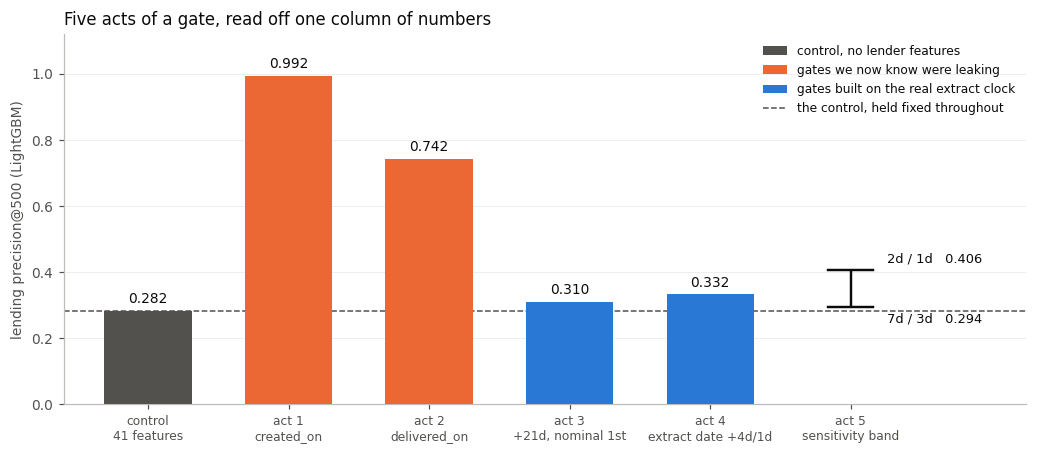

In [5]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(ACTS))
vals = prog["precision_at_500"].to_numpy()
control = vals[0]

colours = [MUTED, ORANGE, ORANGE, BLUE, BLUE]
ax.bar(x, vals, width=0.62, color=colours, zorder=3)
for xi, v in zip(x, vals):
    ax.text(xi, v + 0.025, f"{v:.3f}", ha="center", fontsize=9, color=INK)

# Act 5 is a range rather than a run, so it gets its own slot instead of overlaying act 4.
x5 = len(ACTS)
ax.vlines(x5, band["lender_calib_hi"], band["lender_calib_lo"], color=INK, lw=1.6, zorder=4)
for v, lbl, dy in ((band["lender_calib_lo"], "2d / 1d", 0.035),
                   (band["lender_calib_hi"], "7d / 3d", -0.035)):
    ax.plot([x5 - 0.16, x5 + 0.16], [v, v], color=INK, lw=1.6, zorder=4)
    ax.text(x5 + 0.26, v + dy, f"{lbl}   {v:.3f}", fontsize=8.5, color=INK, va="center")

ax.axhline(control, color=MUTED, lw=1, ls="--", zorder=2)

labels = [lbl for _, lbl, _ in ACTS] + ["act 5\nsensitivity band"]
ax.set_xticks(list(x) + [x5]); ax.set_xticklabels(labels, fontsize=8)
ax.set_xlim(-0.6, x5 + 1.25)
ax.set_ylim(0, 1.12)
ax.set_ylabel("lending precision@500 (LightGBM)")
ax.grid(True, axis="y", alpha=0.7); ax.set_axisbelow(True)
ax.legend(handles=[
    Patch(facecolor=MUTED, label="control, no lender features"),
    Patch(facecolor=ORANGE, label="gates we now know were leaking"),
    Patch(facecolor=BLUE, label="gates built on the real extract clock"),
    Line2D([0], [0], color=MUTED, lw=1, ls="--", label="the control, held fixed throughout"),
], loc="upper right", frameon=False, fontsize=8)
ax.set_title("Five acts of a gate, read off one column of numbers", loc="left", color=INK)
fig.tight_layout()
print(report.save_fig(fig, "19_gate_progression_lending_p500"))
plt.show()

Read left to right, that is the whole post-mortem in one column of numbers: 0.282, then 0.992, then
0.742, then 0.310, then 0.332 with a band from 0.294 to 0.406.

The uncomfortable part is the last two entries. Act 3 was the run the lender verdict was read off,
and act 4, which is strictly more correct about the clock, scores **higher**. A more accurate gate
producing a better score is exactly the pattern you would expect if the gate were still admitting
some information early, and it is what the next section tests directly.

---

# 3. The gate ladder, paired

Three gate settings, all with the same features, the same matrix construction and the same models.
Only the visibility margin differs. Every comparison below is against `refactor_det`, and every one
uses `paired_bootstrap_delta`: the runs score the same companies at the same origins, so the
population noise is common to both and cancels. Notebook 17 shows that the unpaired reading of these
same numbers is inconclusive where the paired reading is not.

**The mechanism, which is what makes this a test rather than an observation.**

- `y_lending` is computed from `Mortgages.NumMortCharges` (`targets.py:298`). That is the same
  register the visibility gate governs. Loosening the gate feeds the model earlier sight of the
  quantity its label is made of, so it leaks the label directly.
- `y_insolvency` comes from a different register entirely. The gate governs its *features* but has no
  path at all to its *label*.

So `insolvency` is not a second data point, it is the **control that isolates the lookahead**. If the
lender features were simply informative, both targets would improve and neither would care where the
gate sits to within a few days. If the gate is leaking, only the target whose label it touches should
respond, and it should respond in proportion.

In [6]:
LADDER = {
    "lender_calib_hi": ("_calib_hi", "7d / 3d"),
    "lender_calib":    ("_calib",    "4d / 1d"),
    "lender_calib_lo": ("_calib_lo", "2d / 1d"),
}


def ladder_config(tag):
    suffix = LADDER[tag][0]
    return replace(train.LENDER_ASOF21, tag=tag,
                   matrix_dir=Path(f"data/processed/model_matrix_lender{suffix}"),
                   eval_dir=Path(f"data/processed/eval_matrix_lender{suffix}"),
                   lender_dir=Path(f"data/processed/lender_panel{suffix}"))


def recorded_predictions(tag, config, target):
    """Reload a recorded run's fitted LightGBM and re-score its held-out rows.

    A reload and a predict, never a refit. Rows come back sorted by (origin, company) so two
    runs can be compared row for row, and the key hash proves they were the same rows.
    """
    split = train.split_origins(target, config)
    df = train.load_origins(target, split.test, config.eval_dir,
                            config.cols(target), config.cats(target))
    with open(STAGE / tag / f"model_{target}.pkl", "rb") as fh:
        model = pickle.load(fh)["lightgbm"]
    df["p"] = model.predict_proba(train.feature_frame(df, config.cols(target)))[:, 1]
    df = df.sort_values(["origin_month", "CompanyNumber"], kind="stable").reset_index(drop=True)
    return {"y": df["y"].to_numpy().astype(np.int8), "p": df["p"].to_numpy(),
            "key": int(pd.util.hash_pandas_object(df["CompanyNumber"], index=False).sum())}


PRED = {}
for t in TARGETS:
    PRED[("refactor_det", t)] = recorded_predictions("refactor_det", train.REFACTOR, t)
for tag in LADDER:
    for t in ("lending", "insolvency"):
        PRED[(tag, t)] = recorded_predictions(tag, ladder_config(tag), t)
for t in ("voluntary_exit", "growth"):
    PRED[("lender_calib_hi", t)] = recorded_predictions("lender_calib_hi",
                                                        ladder_config("lender_calib_hi"), t)
print(f"{len(PRED)} prediction vectors reloaded")

12 prediction vectors reloaded


In [7]:
def paired(tag_a, tag_b, target, n_boot=300):
    a, b = PRED[(tag_a, target)], PRED[(tag_b, target)]
    assert a["key"] == b["key"], f"{target}: {tag_a} and {tag_b} did not score the same rows"
    assert np.array_equal(a["y"], b["y"]), f"{target}: labels differ between runs"
    return train.paired_bootstrap_delta(a["y"], a["p"], b["p"], n_boot=n_boot)


rows = []
for tag, (_, gate) in LADDER.items():
    for t in ("lending", "insolvency"):
        pdelta = paired("refactor_det", tag, t)
        for metric in ("roc_auc", "precision_at_500"):
            m = pdelta[metric]
            rows.append({"target": t, "gate": gate, "tag": tag, "metric": metric,
                         "delta": m["delta"], "lo": m["lo"], "hi": m["hi"],
                         "excludes_zero": bool(m["lo"] > 0 or m["hi"] < 0)})
ladder_paired = pd.DataFrame(rows)

print("LightGBM, paired against refactor_det, 95% intervals")
print(ladder_paired[ladder_paired["metric"] == "roc_auc"]
      .to_string(index=False, float_format=lambda v: f"{v:+.5f}"))
print(report.save_table(ladder_paired, "19_gate_ladder_paired",
                        "Change against the 41-feature control at three visibility gates, "
                        "LightGBM, with paired-bootstrap 95% intervals."))

LightGBM, paired against refactor_det, 95% intervals
    target    gate             tag  metric    delta       lo       hi  excludes_zero
   lending 7d / 3d lender_calib_hi roc_auc -0.00003 -0.00051 +0.00047          False
insolvency 7d / 3d lender_calib_hi roc_auc +0.00072 -0.00015 +0.00170          False
   lending 4d / 1d    lender_calib roc_auc +0.00434 +0.00345 +0.00524           True
insolvency 4d / 1d    lender_calib roc_auc +0.00173 +0.00081 +0.00267           True
   lending 2d / 1d lender_calib_lo roc_auc +0.00563 +0.00457 +0.00661           True
insolvency 2d / 1d lender_calib_lo roc_auc +0.00060 -0.00035 +0.00153          False
reports/tables/19_gate_ladder_paired.tex


In [8]:
# The same three gates for the other two families, from the recorded point estimates. Their fitted
# models were not persisted, so these cannot be paired; they are shown to establish the pattern
# across families, not to carry the interval.
ctrl = idx[idx["tag"] == "refactor_det"].set_index(["target", "model"])
pts = []
for tag, (_, gate) in LADDER.items():
    run = idx[idx["tag"] == tag].set_index(["target", "model"])
    for t in ("lending", "insolvency"):
        for fam in MODELS:
            pts.append({"target": t, "model": fam, "gate": gate,
                        "d_roc_auc": run.loc[(t, fam), "roc_auc"] - ctrl.loc[(t, fam), "roc_auc"],
                        "d_precision_at_500": (run.loc[(t, fam), "precision_at_500"]
                                               - ctrl.loc[(t, fam), "precision_at_500"])})
ladder_pts = pd.DataFrame(pts)
wide = ladder_pts.pivot_table(index=["target", "model"], columns="gate",
                              values="d_roc_auc")[["7d / 3d", "4d / 1d", "2d / 1d"]]
wide["monotone_rising"] = (wide["7d / 3d"] < wide["4d / 1d"]) & (wide["4d / 1d"] < wide["2d / 1d"])
print(wide.to_string(float_format=lambda v: f"{v:+.4f}"))
print(report.save_table(ladder_pts, "19_gate_ladder_all_families",
                        "Change against the control at three visibility gates, all three "
                        "model families, point estimates."))

gate                 7d / 3d  4d / 1d  2d / 1d  monotone_rising
target     model                                               
insolvency lightgbm  +0.0007  +0.0017  +0.0006            False
           logistic  +0.0023  +0.0023  +0.0023            False
           mlp       -0.0039  -0.0026  -0.0019             True
lending    lightgbm  -0.0000  +0.0043  +0.0056             True
           logistic  +0.0036  +0.0053  +0.0070             True
           mlp       +0.0045  +0.0056  +0.0077             True
reports/tables/19_gate_ladder_all_families.tex


reports/figures/19_gate_ladder_paired.pdf


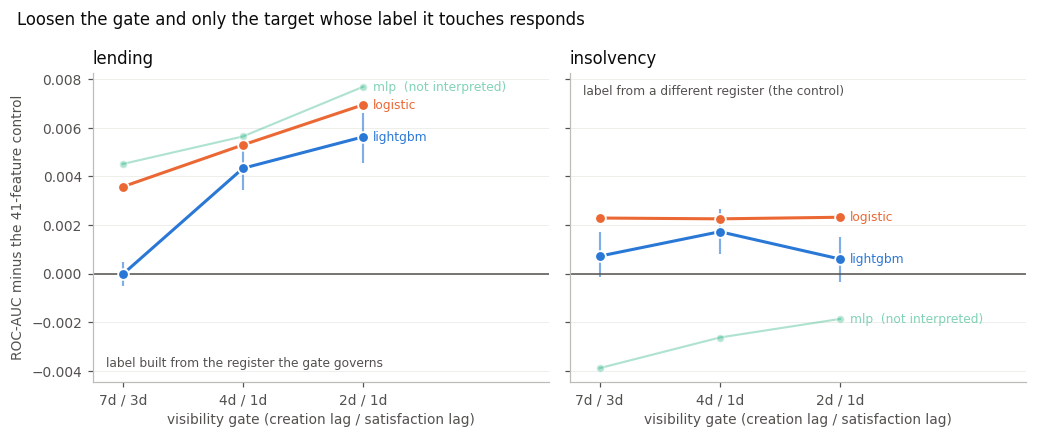

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0), sharey=True)
gates = ["7d / 3d", "4d / 1d", "2d / 1d"]
x = np.arange(len(gates))

for ax, t in zip(axes, ("lending", "insolvency")):
    for fam in MODELS:
        v = [ladder_pts[(ladder_pts["target"] == t) & (ladder_pts["model"] == fam)
                        & (ladder_pts["gate"] == g)]["d_roc_auc"].iloc[0] for g in gates]
        dim = fam == "mlp"
        ax.plot(x, v, "-o", lw=2 if not dim else 1.4, ms=7 if not dim else 5,
                color=FAMILY[fam], markeredgecolor="white", markeredgewidth=1.2,
                alpha=0.35 if dim else 1.0, zorder=3)
        ax.text(x[-1] + 0.08, v[-1], fam + ("  (not interpreted)" if dim else ""),
                color=FAMILY[fam], fontsize=8, va="center", alpha=0.55 if dim else 1.0)
    pl = (ladder_paired[(ladder_paired["target"] == t) & (ladder_paired["metric"] == "roc_auc")]
          .set_index("gate").loc[gates])
    ax.vlines(x, pl["lo"], pl["hi"], color=BLUE, lw=1.4, alpha=0.6, zorder=2)
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_xticks(x); ax.set_xticklabels(gates)
    ax.set_xlim(-0.25, len(gates) + 0.55)
    ax.grid(True, axis="y", alpha=0.7); ax.set_axisbelow(True)
    ax.set_xlabel("visibility gate (creation lag / satisfaction lag)")
    ax.set_title(t, loc="left", color=INK)

axes[0].set_ylabel("ROC-AUC minus the 41-feature control")
axes[0].text(0.03, 0.04, "label built from the register the gate governs",
             transform=axes[0].transAxes, fontsize=8, color=MUTED, va="bottom")
axes[1].text(0.03, 0.96, "label from a different register (the control)",
             transform=axes[1].transAxes, fontsize=8, color=MUTED, va="top")
fig.suptitle("Loosen the gate and only the target whose label it touches responds",
             x=0.02, ha="left", color=INK)
fig.tight_layout()
print(report.save_fig(fig, "19_gate_ladder_paired"))
plt.show()

**`lending` rises monotonically in all nine cells.** Three gates, three model families, no exception.
On LightGBM, the family we can pair, the two looser gates are clear of zero on the paired interval
and precision@500 runs 0.294, 0.332, 0.406 against a control of 0.282.

**`insolvency` does not.** The logistic sits flat at about +0.0023 at all three gates, which is what
a small genuine feature gain looks like: present, and indifferent to the margin. LightGBM is positive
but unordered (+0.0007, +0.0017, +0.0006).

**The MLP rows are drawn faded and are deliberately not part of the argument.** Notebook 17 measured
the growth MLP across four seeds and found a spread of 0.018 of ROC-AUC, four to seven times its
bootstrap interval, with the sign of a 0.0075 difference flipping between seeds. Every MLP delta on
this figure is smaller than 0.009, so all of them sit inside that family's refit noise and none of
them can carry weight.

**Dropping them makes the argument stronger, not weaker.** The monotone pattern on `lending` survives
on the two families that are reproducible given their seed, which means it cannot be explained as
initialisation luck. Had the result depended on the one family whose refits scatter, the honest
reading would have been that we could not tell. It does not.

**What the ladder licenses us to say.** Some of what `lender_calib` gains on `lending` is still
lookahead. A feature set carrying genuine information does not care about a few days of visibility
margin; one that partially anticipates its own label cares, and cares in proportion. The gradient is
the signature, and `insolvency` shows it is not a general property of the feature set.

---

# 4. The corrected V3 verdict

The verdict is read at the **tightest gate tested**, `lender_calib_hi` (7 days on creation, 3 on
satisfaction), because section 3 established that looser gates are partly reading the label on
`lending`. That is the conservative choice and it is the one the report should quote.

In [10]:
verdict_rows = []
hi = idx[idx["tag"] == "lender_calib_hi"].set_index(["target", "model"])
for t in TARGETS:
    for fam in MODELS:
        c, r = ctrl.loc[(t, fam)], hi.loc[(t, fam)]
        overlap = bool(c["roc_auc_hi"] > r["roc_auc_lo"] and r["roc_auc_hi"] > c["roc_auc_lo"])
        verdict_rows.append({
            "target": t, "model": fam,
            "control_roc_auc": c["roc_auc"], "lender_roc_auc": r["roc_auc"],
            "d_roc_auc": r["roc_auc"] - c["roc_auc"],
            "unpaired_intervals_overlap": overlap,
            "d_precision_at_500": r["precision_at_500"] - c["precision_at_500"],
        })
verdict = pd.DataFrame(verdict_rows)

# LightGBM is the one family whose models were persisted, so it is the one we can pair.
for t in TARGETS:
    pdelta = paired("refactor_det", "lender_calib_hi", t)
    m = pdelta["roc_auc"]
    sel = (verdict["target"] == t) & (verdict["model"] == "lightgbm")
    verdict.loc[sel, "paired_lo"] = m["lo"]
    verdict.loc[sel, "paired_hi"] = m["hi"]
    verdict.loc[sel, "paired_excludes_zero"] = bool(m["lo"] > 0 or m["hi"] < 0)

print(verdict.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(report.save_table(verdict, "19_verdict_by_model",
                        "The V3 verdict at the tightest gate tested (7d/3d), per target and "
                        "model family, against the 41-feature control."))

        target    model  control_roc_auc  lender_roc_auc  d_roc_auc  unpaired_intervals_overlap  d_precision_at_500  paired_lo  paired_hi paired_excludes_zero
       lending lightgbm          +0.8767         +0.8766    -0.0000                        True             +0.0120    -0.0005    +0.0005                False
       lending logistic          +0.8615         +0.8651    +0.0036                        True             +0.0380        NaN        NaN                  NaN
       lending      mlp          +0.8672         +0.8717    +0.0045                        True             -0.0700        NaN        NaN                  NaN
    insolvency lightgbm          +0.7615         +0.7622    +0.0007                        True             +0.0020    -0.0002    +0.0017                False
    insolvency logistic          +0.7324         +0.7347    +0.0023                        True             +0.0100        NaN        NaN                  NaN
    insolvency      mlp          +0.7437      

**The verdict, per family.**

- **LightGBM: nothing, anywhere, and on two targets very slightly worse.** The largest absolute
  change across all four targets is 0.0007 of ROC-AUC. On `lending` and `insolvency` the paired
  interval includes zero. On `voluntary_exit` and `growth` it **excludes zero on the negative side**,
  at -0.0002 and -0.0005. I checked that rather than assumed it, and it is worth stating precisely:
  the paired test is sharp enough to resolve a two-ten-thousandth degradation, and what it is
  resolving is the cost of handing a boosted model thirteen columns it cannot use. So this is not
  merely "no evidence of a gain", it is a measured absence of one with a sign on it, which is a
  stronger claim than a null. Twenty-five hours of harvesting, and the model extracts nothing it was
  not already getting from `Mortgages.NumMortCharges`, `NumMortOutstanding` and `NumMortSatisfied`,
  which have been in the 41-feature base set since the beginning.
- **Logistic: a real gain, and the interesting one.** `growth` improves by **+0.0092** with
  non-overlapping intervals even on the conservative unpaired reading. `lending` (+0.0036) and
  `insolvency` (+0.0023) move in the same direction but their unpaired intervals overlap, and we
  cannot pair them because only the LightGBM models were persisted. So: one clear gain, two
  suggestive.
- **MLP: not interpreted**, per the seed standard from notebook 17.

**What that locates.** The lender columns refine information the base model already holds, minus
lender identity. A gradient-boosted model can already extract it from the raw counts; a linear model
cannot, because it cannot form the interactions, and it gains materially from the better encoding.
**The finding is about encoding, not about information**, and that is a more useful result than a flat
null, because it tells you when the harvest would be worth repeating: for a linear or
interpretability-constrained model, not for the boosted one we actually deploy.

**Caveat 1: 7d/3d is the tightest gate we tested, not a gate proven clean.** The `lending` gradient
has not flattened at 7d/3d. It is still rising from that point, which means we do not know where the
lookahead ends; we only know it is smaller there than at 4d/1d. A fourth rung at, say, 14d/7d would
tell us whether the curve turns over, and until someone runs it the honest statement is "the
lookahead is bounded above by what we see at the tightest setting tested", not "eliminated".

**Caveat 2: the most impressive number in the project is one we are throwing away.** `lender_calib_lo`
puts `lending` precision@500 at **0.406** against a control of 0.282, a 44% improvement and a lift of
150x over the base rate. It is the number any reader would want in the abstract. We are naming it as
**discarded**, because it comes from the loosest gate on the ladder and section 3 shows that the
loosest gate is the one reading the most of its own label. Reporting it would be reporting the leak
we spent the day finding. That is worth stating explicitly in the chapter rather than quietly
omitting, because a reader who later finds 0.406 in `index.csv` should find our reasoning next to it.

---

# 5. The growth fix

Full derivation is in `notebooks/18_growth_defect.ipynb`; this section states the result and cites it
rather than re-deriving. I am taking Stream C's corrected mechanism, which supersedes the account I
gave the coordinator earlier.

**The defect.** `split_origins` fell back for `growth`: `MIN_TRAIN_ORIGINS = 3` silently disabled the
`targets.FIRST_FULL_ORIGIN` guard, so the model trained on 2023-10, 2024-01 and 2024-04, where the
twelve-month deltas are 100% NULL, and tested on 2025-04 and 2025-07, where they are populated. The
guard existed to prevent exactly this and `train.py:363` named the failure mode in advance.

**The corrected mechanism, which matters for reading the before-and-after.** The effective feature
count was **32 for every family**, not 41 and not a different number per family:

- Nine features are 100% NULL across all three training origins. LightGBM takes **zero splits** on
  them (`mean_abs_shap` exactly 0.000000, ranks 33 to 41 in
  `reports/runs/refactor/shap_importance_growth.csv`). For the logistic and the MLP, scikit-learn's
  `SimpleImputer` **drops them outright** with a warning, because a column with no observed value has
  no median to impute. Different route, same destination: nine columns reach no model.
- So before and after differ by the **five remaining partially-missing columns**, identically for all
  three families. That is the whole of the treatment effect.

**The result.** Those five columns move two families in opposite directions: logistic **+0.0035**,
LightGBM **-0.0010**. The MLP's +0.0075 is not interpreted, because notebook 17 showed its sign flips
across seeds.

In [11]:
gf = idx[(idx["tag"] == "refactor_growthfix") & (idx["target"] == "growth")].set_index("model")
gc = idx[(idx["tag"] == "refactor_det") & (idx["target"] == "growth")].set_index("model")
growth = pd.DataFrame([{
    "model": m,
    "n_features_before": int(gc.loc[m, "n_features"]),
    "n_features_after": int(gf.loc[m, "n_features"]),
    "roc_auc_before": gc.loc[m, "roc_auc"], "roc_auc_after": gf.loc[m, "roc_auc"],
    "d_roc_auc": gf.loc[m, "roc_auc"] - gc.loc[m, "roc_auc"],
    "unpaired_intervals_overlap": bool(gc.loc[m, "roc_auc_hi"] > gf.loc[m, "roc_auc_lo"]
                                       and gf.loc[m, "roc_auc_hi"] > gc.loc[m, "roc_auc_lo"]),
    "interpreted": m != "mlp",
} for m in MODELS])
print(growth.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(report.save_table(growth, "19_growth_fix",
                        "The growth feature fix: 41 nominal columns against 27, where the "
                        "effective count was 32 for every family either way."))

   model  n_features_before  n_features_after  roc_auc_before  roc_auc_after  d_roc_auc  unpaired_intervals_overlap  interpreted
lightgbm                 41                27         +0.7620        +0.7611    -0.0010                        True         True
logistic                 41                27         +0.7290        +0.7324    +0.0035                        True         True
     mlp                 41                27         +0.6941        +0.7016    +0.0075                       False        False
reports/tables/19_growth_fix.tex


Note the column that matters and is easy to misread: `n_features` records 41 against 27, which is the
**nominal** list. The effective count was 32 in both the before and the after case, and the fix moved
five columns, not fourteen. A reader given only the 41-versus-27 headline would over-attribute the
change by a factor of nearly three.

The other three targets are untouched by the fix, which is what makes it a clean A/B, and their rows
in `refactor_growthfix` reproduce `refactor_det` exactly.

---

# 6. Methods and limitations

Three findings about measurement came out of this that are, I think, more transferable than anything
we learned about lending. None of them is exotic. All three were sitting in artefacts we had already
produced and had already read.

**1. A pooled precision@N is not an average of the months it pools.** It is computed on both test
origins stacked together, so it can fall outside the range of the two monthly figures in either
direction. That happens in **9 of 12** target-and-family rows, and independently on both
`refactor_det` and `lender_calib`: six of the nine miss by more than 0.02 and three are marginal, at
0.002 to 0.006. Two directions, two mechanisms. Pooling can **flatter** (`lending` LightGBM: pooled
0.282 against months of 0.218 and 0.226) because taking the best 500 of two months of candidates
means going less deep into either list. It can also **penalise** (`voluntary_exit` logistic: pooled
0.296 against 0.404 and 0.450), which can only happen if the scores are not comparable across
origins, so the pooled list fills with rows from whichever month scores higher in absolute terms
regardless of which month it ranks better in. For anything presented as an operational call list,
quote the per-origin figure and its spread.

**2. precision@N on `voluntary_exit` is partly arbitrary.** **982 of the top 1000** scores are exact
ties, to the last bit, because a saturated boosted model puts several hundred thousand companies on
the same leaf pattern. `np.argpartition` then returns some arbitrary 500 of that tied block, so the
metric is resolving ties rather than ranking. A relative perturbation of 1e-15, which is what two
processes produce for free through BLAS reduction order, moves precision@500 by 0.004. That is the
entire explanation for the run-to-run wobble we spent an afternoon attributing to model
nondeterminism, and the model was bit-identical the whole time.

**3. The row bootstrap is the whole error bar for two families and misses the dominant term for the
third.** Resampling evaluation rows quantifies "which companies happened to be in the test period".
For LightGBM (seed spread 0.0006 on `growth`) and the logistic (0.0009) that is genuinely all of it.
For the MLP, whose fit starts from a random initialisation and whose seed also selects its 300k
training rows, the seed spread is 0.008 to 0.013, four to seven times the bootstrap width. Quoting
a bootstrap interval for an MLP is quoting the smaller of two error terms and calling it the total.

**The pattern connecting all three**, and the reason the framing sentence at the top is the right one:
each of these was a check that ran, returned a clean-looking answer, and was believed. The pooled P@N
looked like an average. The tied top-500 looked like a ranking. The bootstrap looked like a
confidence interval. None of them was wrong about what it computed; all three were wrong about what
we thought they meant.

**What remains undone**, stated so the next person does not have to rediscover it:

1. Only LightGBM models were persisted by the staged runner, so **only LightGBM comparisons can be
   paired**. The logistic gains in section 4 are the ones the verdict most depends on and they are the
   ones we cannot test properly. Persisting the held-out prediction vector per run and per family is a
   few megabytes and would fix this permanently.
2. **The gate ladder has no rung above 7d/3d**, so the lookahead is bounded but not located.
3. **MLP numbers are single-seed** throughout. Averaging over several seeds inside `run_target` would
   make them quotable; until then they are excluded from load-bearing arguments.
4. `registration_lag_days` in the four lender manifests records the module default rather than the
   gate the panel was built under. The true settings are in `scripts/run_config_staged.py` and
   `src/features/charges.py`. Fixed for future runs in `train.py`; the recorded four are wrong in that
   one field.

---

## What to check

Every claim in this notebook is re-derived from disk below.

In [12]:
checks = []


def check(name, ok, detail=""):
    checks.append({"check": name, "pass": bool(ok), "detail": str(detail)})


check("index.csv holds 11 tags", idx["tag"].nunique() == 11, idx["tag"].nunique())
check("baseline has 8 rows because it predates the MLP",
      len(idx[idx["tag"] == "baseline"]) == 8 and
      set(idx[idx["tag"] == "baseline"]["model"]) == {"lightgbm", "logistic"},
      sorted(set(idx[idx["tag"] == "baseline"]["model"])))
check("every tag recorded after the bootstrap landed carries intervals throughout",
      int(coverage["intervals"].sum()) == 6,
      f"{int(coverage['intervals'].sum())} with, "
      f"{int((~coverage['intervals']).sum())} without: "
      f"{sorted(coverage.index[~coverage['intervals']])}")
check("no interval is silently blank in the exported table",
      (all_runs["roc_auc_ci"].str.len() > 0).all() and
      (all_runs["roc_auc_ci"] == "not recorded").sum() == int((~runs["has_interval"]).sum()),
      f"{int((all_runs['roc_auc_ci'] == 'not recorded').sum())} cells marked not recorded")

# The gate story.
check("act 1 leaks: lending P@500 above 0.99",
      prog.loc[prog["tag"] == "lender", "precision_at_500"].iloc[0] > 0.99,
      prog.loc[prog["tag"] == "lender", "precision_at_500"].iloc[0])
check("the calibrated gate scores higher than the flat 21-day gate",
      prog.loc[prog["tag"] == "lender_calib", "precision_at_500"].iloc[0]
      > prog.loc[prog["tag"] == "lender_asof21", "precision_at_500"].iloc[0],
      f"{prog.loc[prog['tag'] == 'lender_asof21', 'precision_at_500'].iloc[0]:.3f} -> "
      f"{prog.loc[prog['tag'] == 'lender_calib', 'precision_at_500'].iloc[0]:.3f}")

# The ladder.
lend_w = wide.loc["lending"]
check("lending rises monotonically across the ladder in all three families",
      bool(lend_w["monotone_rising"].all()), lend_w["monotone_rising"].to_dict())
check("lending is monotone in the two families we do interpret",
      bool(lend_w.loc[["lightgbm", "logistic"], "monotone_rising"].all()))
check("insolvency is not monotone across the ladder in LightGBM",
      not bool(wide.loc[("insolvency", "lightgbm"), "monotone_rising"]),
      wide.loc["insolvency"].drop(columns="monotone_rising").round(4).to_dict("index"))
check("insolvency logistic is flat across the ladder (range below 0.001)",
      float(wide.loc[("insolvency", "logistic")][gates].max()
            - wide.loc[("insolvency", "logistic")][gates].min()) < 0.001,
      float(wide.loc[("insolvency", "logistic")][gates].max()
            - wide.loc[("insolvency", "logistic")][gates].min()))
check("the two looser gates are clear of zero on lending, paired",
      bool(ladder_paired[(ladder_paired["target"] == "lending")
                         & (ladder_paired["metric"] == "roc_auc")
                         & (ladder_paired["gate"] != "7d / 3d")]["excludes_zero"].all()))
check("every MLP delta on the ladder is inside the MLP seed noise of 0.018",
      bool((ladder_pts[ladder_pts["model"] == "mlp"]["d_roc_auc"].abs() < 0.018).all()),
      float(ladder_pts[ladder_pts["model"] == "mlp"]["d_roc_auc"].abs().max()))

# The verdict.
check("LightGBM gains nothing at the tightest gate on any target",
      float(verdict[verdict["model"] == "lightgbm"]["d_roc_auc"].abs().max()) < 0.001,
      float(verdict[verdict["model"] == "lightgbm"]["d_roc_auc"].abs().max()))
lgb_v = verdict[verdict["model"] == "lightgbm"]
check("no LightGBM paired interval at the tightest gate excludes zero on the positive side",
      not bool((lgb_v["paired_excludes_zero"] & (lgb_v["d_roc_auc"] > 0)).any()),
      lgb_v.set_index("target")["d_roc_auc"].round(5).to_dict())
check("the two LightGBM intervals that do exclude zero are both negative",
      bool((lgb_v[lgb_v["paired_excludes_zero"]]["d_roc_auc"] < 0).all())
      and int(lgb_v["paired_excludes_zero"].sum()) == 2,
      lgb_v[lgb_v["paired_excludes_zero"]].set_index("target")["d_roc_auc"].round(5).to_dict())
check("the logistic gain on growth survives even the unpaired reading",
      not bool(verdict[(verdict["target"] == "growth")
                       & (verdict["model"] == "logistic")]["unpaired_intervals_overlap"].iloc[0]),
      float(verdict[(verdict["target"] == "growth")
                    & (verdict["model"] == "logistic")]["d_roc_auc"].iloc[0]))
check("the discarded _lo run really is the best lending P@500 on record",
      float(idx[(idx["target"] == "lending") & (idx["model"] == "lightgbm")
                & (~idx["tag"].isin(["lender", "lender_fixed"]))]["precision_at_500"].max())
      == float(idx[(idx["tag"] == "lender_calib_lo") & (idx["target"] == "lending")
                   & (idx["model"] == "lightgbm")]["precision_at_500"].iloc[0]),
      "0.406 at 2d/1d, excluding the two runs we know were leaking")

# The growth fix.
check("the growth fix leaves the other three targets identical to the control",
      bool(np.allclose(
          idx[(idx["tag"] == "refactor_growthfix") & (idx["target"] != "growth")]
          .sort_values(["target", "model"])["roc_auc"].to_numpy(),
          idx[(idx["tag"] == "refactor_det") & (idx["target"] != "growth")]
          .sort_values(["target", "model"])["roc_auc"].to_numpy())))
check("the growth fix moves logistic and LightGBM in opposite directions",
      float(growth[growth["model"] == "logistic"]["d_roc_auc"].iloc[0]) > 0
      > float(growth[growth["model"] == "lightgbm"]["d_roc_auc"].iloc[0]),
      growth.set_index("model")["d_roc_auc"].round(4).to_dict())

# The metrology findings, re-derived from notebook 17's saved tables.
per_origin = pd.read_csv("reports/tables/17_per_origin_spread.csv")
pcols = [c for c in per_origin.columns if c.startswith("p500_")]
counts = {}
for tag, g in per_origin.groupby("tag"):
    n_out = 0
    for _, r in g.iterrows():
        per = [r[c] for c in pcols if pd.notna(r[c])]
        n_out += int(r["pooled_p500"] < min(per) or r["pooled_p500"] > max(per))
    counts[tag] = f"{n_out} of {len(g)}"
check("pooled P@500 falls outside its own months' range in 9 of 12 rows, on both tags",
      all(v == "9 of 12" for v in counts.values()), counts)

gaps = pd.read_csv("reports/tables/17_rank_gap_fragility.csv").set_index("target")
check("982 of the top 1000 voluntary_exit scores are exact ties",
      int(gaps.loc["voluntary_exit", "exact_ties_in_top_1000"]) == 982,
      int(gaps.loc["voluntary_exit", "exact_ties_in_top_1000"]))

seed = pd.read_csv("reports/tables/17_growth_seed_spread.csv")
check("the MLP seed range exceeds its bootstrap width; the other two families' do not",
      bool((seed[seed["model"] == "mlp"]["seed_range_over_bootstrap_width"] > 1).all()
           and (seed[seed["model"] != "mlp"]["seed_range_over_bootstrap_width"] < 1).all()),
      seed.set_index(["features", "model"])["seed_range_over_bootstrap_width"].round(2).to_dict())

checks_df = pd.DataFrame(checks)
print(checks_df[["check", "pass"]].to_string(index=False))
print()
print(f"{checks_df['pass'].sum()} of {len(checks_df)} checks pass")
print(report.save_table(checks_df, "19_checks", "Machine-checked assertions for notebook 19."))
assert checks_df["pass"].all(), checks_df[~checks_df["pass"]]

                                                                              check  pass
                                                            index.csv holds 11 tags  True
                                    baseline has 8 rows because it predates the MLP  True
         every tag recorded after the bootstrap landed carries intervals throughout  True
                                no interval is silently blank in the exported table  True
                                              act 1 leaks: lending P@500 above 0.99  True
                        the calibrated gate scores higher than the flat 21-day gate  True
                lending rises monotonically across the ladder in all three families  True
                            lending is monotone in the two families we do interpret  True
                           insolvency is not monotone across the ladder in LightGBM  True
                  insolvency logistic is flat across the ladder (range below 0.001)  True
          

---

## For the report

**Drafted paragraphs**, written to be pasted into the results chapter.

> **The lender feature verdict.** Thirteen features derived from the Companies House Charges API were
> evaluated against a 41-feature control on four targets and three model families, using an
> out-of-time split with an embargo and an unsampled evaluation population. Read at the tightest
> visibility gate tested, the gradient-boosted model shows no gain on any target: the largest absolute
> difference is 0.0007 of ROC-AUC, no paired bootstrap interval excludes zero in the positive
> direction, and on two of the four targets the interval excludes zero negatively (-0.0002 and
> -0.0005), consistent with the small cost of supplying additional columns the model cannot exploit.
> The regularised logistic
> regression improves materially on the growth target (+0.0092, non-overlapping intervals) and
> directionally on lending (+0.0036) and insolvency (+0.0023). The multi-layer perceptron is excluded
> from interpretation, as its refit variation across seeds exceeds every effect measured here. The
> lender columns therefore refine information already present in the mortgage-count fields of the base
> feature set: a boosted model extracts that information without them, whereas a linear model cannot
> form the necessary interactions and gains from the improved encoding. The finding concerns encoding
> rather than information content, which locates the practical value of the harvest in
> interpretability-constrained settings rather than in the deployed model.

> **Evidence of residual lookahead.** The visibility gate was evaluated at three settings spanning the
> calibrated estimate (7/3, 4/1 and 2/1 days on charge creation and satisfaction respectively). On the
> lending target, whose label is derived from the same charge register the gate governs, the advantage
> over the control rises monotonically as the gate is loosened, without exception across all three
> model families, and precision@500 rises from 0.294 to 0.406. On the insolvency target, whose label
> derives from an unrelated register and which therefore functions as a control isolating the
> lookahead, no such ordering exists and the linear model's advantage is constant at +0.0023 across
> all three settings. A feature set carrying genuine information is insensitive to a few days of
> visibility margin; one that partially anticipates its own label is not. The remaining lending
> advantage is therefore at least partly anticipatory. Because the gradient has not flattened at the
> tightest setting tested, the lookahead is bounded above rather than eliminated, and the strongest
> result obtained (precision@500 of 0.406 at the loosest gate, a 44% improvement over the control) is
> reported here only as discarded.

> **Measurement limitations.** Three properties of the evaluation metrics were identified that
> constrain interpretation. First, precision@N pooled across test origins is not an average of the
> per-origin figures and falls outside their range in 9 of 12 target-family combinations, in both
> directions; per-origin figures are therefore reported for any operational interpretation. Second, on
> the voluntary-exit target 982 of the top 1000 predicted scores are exactly equal, so precision@N
> there resolves ties rather than ranks, and is sensitive to perturbations of order 1e-15. Third,
> confidence intervals obtained by resampling evaluation rows capture the dominant source of variation
> for the boosted and linear models but not for the neural network, whose seed-to-seed refit variation
> is four to seven times larger; results for that family are accordingly not interpreted at the
> magnitudes observed.

**Figures**

| path | use |
|---|---|
| `reports/figures/19_gate_progression_lending_p500.pdf` | **the chapter's spine: five acts of the gate** |
| `reports/figures/19_gate_ladder_paired.pdf` | the lookahead evidence, paired, MLP faded out |
| `reports/figures/17_gate_ladder_contrast.pdf` | notebook 17's version, if the methods chapter wants it too |
| `reports/figures/17_growth_seed_spread_vs_bootstrap.pdf` | why the MLP is excluded |
| `reports/figures/17_rank_gap_vs_numerical_wobble.pdf` | why precision@N quantises |
| `reports/figures/17_per_origin_p500_spread.pdf` | pooled against per-origin |

**Tables**

| path | use |
|---|---|
| `reports/tables/19_all_runs.csv` / `.tex` | the full results appendix |
| `reports/tables/19_gate_progression.csv` / `.tex` | the five acts |
| `reports/tables/19_gate_ladder_paired.csv` / `.tex` | the ladder with paired intervals |
| `reports/tables/19_gate_ladder_all_families.csv` / `.tex` | the ladder, all families |
| `reports/tables/19_verdict_by_model.csv` / `.tex` | **the verdict table** |
| `reports/tables/19_growth_fix.csv` / `.tex` | the growth before-and-after |
| `reports/tables/19_checks.csv` / `.tex` | the verification list |

**Reading order for a reviewer.** `nb16` for the leak and the gate calibration, `14b` for the
verification that could not fail and what replaced it, `18` for the growth defect, `17` for the
evaluation methods, and this notebook for the numbers. `99_showcase` points at all of them.